In [1]:
!pip install pingouin

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
# from heatindex import heatindex
from datetime import datetime
import numpy as np
import pingouin as pg

tqdm.pandas()

In [3]:
outdoor_heat = pd.read_csv('./campaign_data/outdoor_heat.csv')

# Convert 'Date/Time' to datetime format
outdoor_heat['Date/Time'] = pd.to_datetime(outdoor_heat['Date/Time'])

# Set 'Date/Time' as the index
outdoor_heat.set_index('Date/Time', inplace=True)

outdoor_heat['Hour'] = outdoor_heat.index.hour

indoor_heat = pd.read_csv('./campaign_data/indoor_heat.csv')

# Convert 'Date/Time' to datetime format
indoor_heat['Date/Time'] = pd.to_datetime(indoor_heat['Date/Time'])

# Set 'Date/Time' as the index
indoor_heat.set_index('Date/Time', inplace=True)

indoor_heat['Hour'] = indoor_heat.index.hour

/tmp/ipykernel_40913/454144469.py:1: DtypeWarning: Columns (12,31) have mixed types. Specify dtype option on import or set low_memory=False.
  outdoor_heat = pd.read_csv('./campaign_data/outdoor_heat.csv')
/tmp/ipykernel_40913/454144469.py:11: DtypeWarning: Columns (9,13,36,99,103) have mixed types. Specify dtype option on import or set low_memory=False.
  indoor_heat = pd.read_csv('./campaign_data/indoor_heat.csv')


In [ ]:
indoor_heat[]

In [4]:
ndvi_values = pd.read_csv('updated_sites_lat_long_ndvi.csv')
ndbi_values = pd.read_csv('updated_sites_lat_long_ndbi.csv')
common_sites = set(indoor_heat['site_id']).intersection(set(outdoor_heat['site_id']))

In [5]:
# Rename 'Value' column in indoor dataframe to avoid confusion after merge
indoor_heat['Original_Indoor_Time'] = indoor_heat.index.round('H').hour
# outdoor_heat['Original_Outdoor_Time'] = outdoor_heat.index.round('H').hour

# Sort both dataframes by 'Date/Time' and 'site_id'
outdoor_heat.sort_values(['Date/Time', 'site_id'], inplace=True)
indoor_heat.sort_values(['Date/Time', 'site_id'], 
                        inplace=True)

# Merge the dataframes
merged_df = pd.merge_asof(indoor_heat, outdoor_heat, 
                          on='Date/Time', by='site_id', 
                          tolerance=pd.Timedelta('1 hour'), direction='nearest', suffixes = ('_outdoor', '_indoor'))

merged_df['heat_diff'] = merged_df['Indoor_Heat_Index'] - merged_df['Outdoor_Heat_Index']
merged_df['Date/Time'] = pd.to_datetime(merged_df['Date/Time'])
merged_df['Day/night'] = merged_df['Date/Time'].dt.hour.apply(lambda x: 'Day' if 6 <= x < 18 else 'Night')


In [6]:
# Assuming merged_df and ndvi_values are already loaded as described
# Convert 'site_id' to string if not already (in both dataframes)
merged_df['site_id'] = merged_df['site_id'].astype(str)
ndvi_values['site_id'] = ndvi_values['site_id'].astype(str)
ndbi_values['site_id'] = ndbi_values['site_id'].astype(str)

# Merge NDVI values with merged_df
merged_df = pd.merge(merged_df, ndvi_values[['site_id', 'mean_ndvi']], on='site_id', how='left')
# Merge NDVI values with merged_df
merged_df = pd.merge(merged_df, ndbi_values[['site_id', 'mean_ndbi']], on='site_id', how='left')

# Now merged_df contains the NDVI values along with other data


In [7]:
# Assuming your dataframe has a datetime column named "timestamp"
merged_df['Date'] = merged_df['Date/Time'].dt.date

# Step 1: Day-Level Aggregation with 'site_type_outdoor'
day_level = merged_df.groupby(['sensor_id_indoor_temp', 'Date', 'Day/night']).agg(
    daily_mean_indoor=('Indoor_Heat_Index', 'mean'),
    daily_mean_outdoor=('Outdoor_Heat_Index', 'mean'),
    daily_max_indoor=('Indoor_Heat_Index', 'max'),
    daily_max_outdoor=('Outdoor_Heat_Index', 'max'),
    mean_ndvi=('mean_ndvi', 'first'),  # Assuming each sensor_id, Date, Day/night combo has a single site type
    mean_ndbi=('mean_ndbi', 'first')  # Assuming each sensor_id, Date, Day/night combo has a single site type
).reset_index()

# Step 2: Sensor-Level Aggregation
aggregated_data = day_level.groupby(['sensor_id_indoor_temp', 'Day/night']).agg(
    average_daily_mean_indoor=('daily_mean_indoor', 'mean'),
    average_daily_mean_outdoor=('daily_mean_outdoor', 'mean'),
    average_daily_max_indoor=('daily_max_indoor', 'mean'),
    average_daily_max_outdoor=('daily_max_outdoor', 'mean'),
    mean_ndvi=('mean_ndvi', 'first'),
    mean_ndbi=('mean_ndbi', 'first')
).reset_index()

In [12]:
for column in merged_df.columns:
    print(column)

Unnamed: 0_outdoor
Date/Time
point_id_indoor_temp
Unit_x_outdoor
Value_temp_outdoor
sensor_id_indoor_temp
site_id_x
filename_x_outdoor
hh_id_x
hh_notes_x
gps_lat_x
gps_long_x
gps_ghanapost_x
photo_ext_x
photo_int_x
indoor_sensor_deployment_complete_x
sensor_storey
sensor_storey_other
sensor_room
sensor_room_other
windows_yesno
drapes_yesno
aircon_yesno
fan_yesno
paint_colour
paint_type
sat_image
dwelling_type
roof_material
roof_shape
wall_material
floor_material
ceiling_material
roof_wall_gap
roof_colour
window_type
window_type_other
window_orientiation_1
window_orientation_2
number_rooms
dwelling_floors
shade_trees_yesno
shade_buildings_yesno
number_people
number_children
number_elder
housing_tenure_other
dwelling_features_complete
sex
age
housing_tenure
aircon_current
window_current
temperature
breeze
temp_frequency
temp_timeofday
temp_interventions___1
temp_interventions___2
temp_interventions___3
temp_interventions___4
temp_interventions___5
temp_interventions___6
temp_intervention

In [36]:
# merged_df['sensor_id_indoor_temp'].unique()

merged_df[merged_df['sensor_id_indoor_temp'] == "'0557'"]['Value_temp_indoor'].head()

18077   NaN
18081   NaN
18105   NaN
18112   NaN
18117   NaN
Name: Value_temp_indoor, dtype: float64

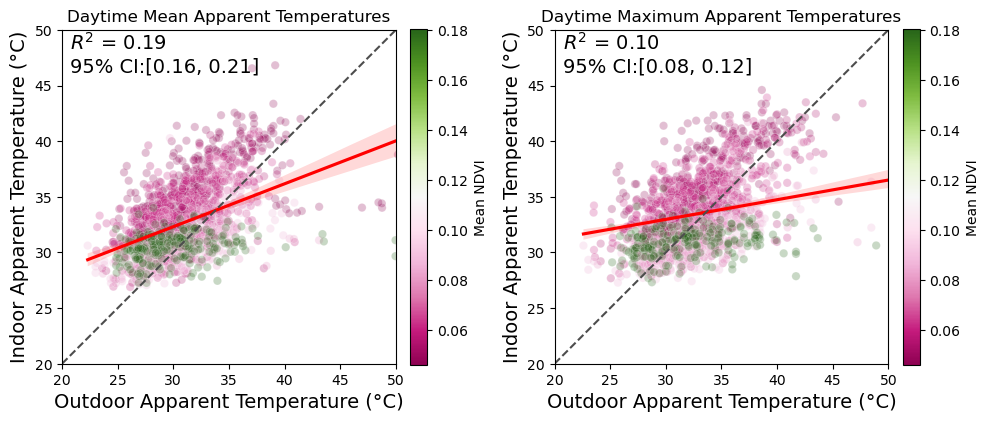

In [15]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

def annotate_fit(x, y, ax):
    # Drop NaN values
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    X = sm.add_constant(df['x'])
    model = sm.OLS(df['y'], X).fit()
    a, b = model.params['const'], model.params['x']
    r2 = model.rsquared
    
    # Calculate the confidence interval for R using Pingouin
    ci = pg.corr(x=df['x'], y=df['y']).loc['pearson', 'CI95%']
    # Square the CI values to get the CI for R^2
    ci_r2 = [value**2 for value in ci]
    
    # ax.annotate(f'Y = {a:.2f} + {b:.2f}X\n$R^2$ = {r2:.2f}, 95% CI: [{ci_r2[0]:.2f}, {ci_r2[1]:.2f}]', 
    #             xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14)
    ax.annotate(f'$R^2$ = {r2:.2f}\n95% CI:[{ci_r2[0]:.2f}, {ci_r2[1]:.2f}]', 
                xy=(0.025, 0.875), xycoords='axes fraction', fontsize=14)

# Choose either 'day_level' or 'aggregated_data' for analysis
analysis_level = 'day_level'  # Set to either 'day' or 'aggregated'
# analysis_level = 'aggregated'  # Set to either 'day' or 'aggregated'

if analysis_level == 'day_level':
    analysis_frame = day_level
    axis_prefix = 'Daily'
elif analysis_level == 'aggregated':
    analysis_frame = aggregated_data
    axis_prefix = 'Average Daily'

day_night = 'Day'  # Change as needed
# day_night = 'Night'  # Change as needed

# Sort the analysis_frame by 'mean_ndvi'
analysis_frame = analysis_frame.sort_values('mean_ndvi')

plt.figure(figsize=(10, 10))  # Adjusted for a square plot

# Helper function to find the common limits
def find_common_limits(series1, series2, upper_bound=None):
    combined = pd.concat([series1, series2], ignore_index=True)
    lower = combined.min()
    upper = combined.max()
    if upper_bound is not None:
        upper = min(upper, upper_bound)
    return lower, upper
    
# Find the common limits for mean temperatures
# mean_limits = find_common_limits(analysis_frame[axis_prefix.lower().replace(' ','_')+'_mean_outdoor'], 
#                                  analysis_frame[axis_prefix.lower().replace(' ','_')+'_mean_indoor'])

mean_limits = 20, 50
# mean_limits = 27.5, 40

# # Custom colormap for NDVI
# cmap = sns.light_palette("green", as_cmap=True)


# Mean average temperatures - modified to color by mean_ndvi
ax1 = plt.subplot(121)
sns.scatterplot(
    data=analysis_frame[analysis_frame['Day/night'] == day_night], 
    x=axis_prefix.lower().replace(' ','_')+'_mean_outdoor', 
    y=axis_prefix.lower().replace(' ','_')+'_mean_indoor',
    hue='mean_ndvi',  # Color by mean NDVI value
    # palette=cmap,
    palette='PiYG',
    alpha=0.25,
    legend=False,  # Temporarily disable legend
    ax=ax1
)

# Add colorbar for NDVI
smc = plt.cm.ScalarMappable(cmap='PiYG', norm=plt.Normalize(vmin=analysis_frame['mean_ndvi'].min(), vmax=analysis_frame['mean_ndvi'].max()))
smc.set_array([])
cbar = plt.colorbar(smc, ax=ax1,fraction=0.046, pad=0.04)
cbar.set_label('Mean NDVI')

sns.regplot(data=analysis_frame[analysis_frame['Day/night'] == day_night], 
            x=axis_prefix.lower().replace(' ','_')+'_mean_outdoor', 
            y=axis_prefix.lower().replace(' ','_')+'_mean_indoor', 
            ax=ax1, 
            scatter = False,
            # scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'}, 
            ci=95)
ax1.set_xlim(mean_limits)
ax1.set_ylim(mean_limits)
ax1.set_aspect('equal')
ax1.plot(mean_limits, mean_limits, ls="--", c=".3")  # x=y line
ax1.set_title(f'{day_night}time Mean Apparent Temperatures')
ax1.set_ylabel('Indoor Apparent Temperature (°C)', fontsize = 14)
ax1.set_xlabel('Outdoor Apparent Temperature (°C)', fontsize = 14)
annotate_fit(analysis_frame[axis_prefix.lower().replace(' ','_')+'_mean_outdoor'], analysis_frame[axis_prefix.lower().replace(' ','_')+'_mean_indoor'], ax1)

if day_night == 'Day':
    # max_limits = find_common_limits(analysis_frame[axis_prefix.lower().replace(' ','_')+'_max_outdoor'], 
    #                                 analysis_frame[axis_prefix.lower().replace(' ','_')+'_max_indoor'],
    #                                 upper_bound=50)  # Set upper bound to 50

    max_limits = mean_limits
    
    # Mean maximum temperatures
    ax2 = plt.subplot(122)
    sns.scatterplot(data=analysis_frame[analysis_frame['Day/night'] == day_night], 
                x=axis_prefix.lower().replace(' ','_')+'_max_outdoor', 
                y=axis_prefix.lower().replace(' ','_')+'_max_indoor',
                hue='mean_ndvi',  # Color by mean NDVI value
                # palette=cmap,
                palette='PiYG',
                alpha=0.25,
                legend=False,  # Temporarily disable legend
                ax=ax2)
    # Add colorbar for NDVI
    smc2 = plt.cm.ScalarMappable(cmap='PiYG', norm=plt.Normalize(vmin=analysis_frame['mean_ndvi'].min(), vmax=analysis_frame['mean_ndvi'].max()))
    smc2.set_array([])
    cbar2 = plt.colorbar(smc2, ax=ax2,fraction=0.046, pad=0.04)
    cbar2.set_label('Mean NDVI')
    sns.regplot(data=analysis_frame[analysis_frame['Day/night'] == day_night], 
                x=axis_prefix.lower().replace(' ','_')+'_max_outdoor', 
                y=axis_prefix.lower().replace(' ','_')+'_max_indoor', 
                ax=ax2, 
                # scatter_kws={'alpha': 0.5}, 
                scatter = False,
                line_kws={'color': 'red'}, 
                ci=95)
    ax2.set_xlim(max_limits)
    ax2.set_ylim(max_limits)
    ax2.set_aspect('equal')
    ax2.plot(max_limits, max_limits, ls="--", c=".3")  # x=y line
    ax2.set_title(f'{day_night}time Maximum Apparent Temperatures')
    ax2.set_ylabel('Indoor Apparent Temperature (°C)', fontsize = 14)
    ax2.set_xlabel('Outdoor Apparent Temperature (°C)', fontsize = 14)
    annotate_fit(analysis_frame[axis_prefix.lower().replace(' ','_')+'_max_outdoor'], analysis_frame[axis_prefix.lower().replace(' ','_')+'_max_indoor'], ax2)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=-0.25)  # Provide space at the bottom for the legend

plt.savefig(f"{analysis_level}_{day_night}_correlation_indoor_outdoor_ndvi_heat.png", bbox_inches='tight')


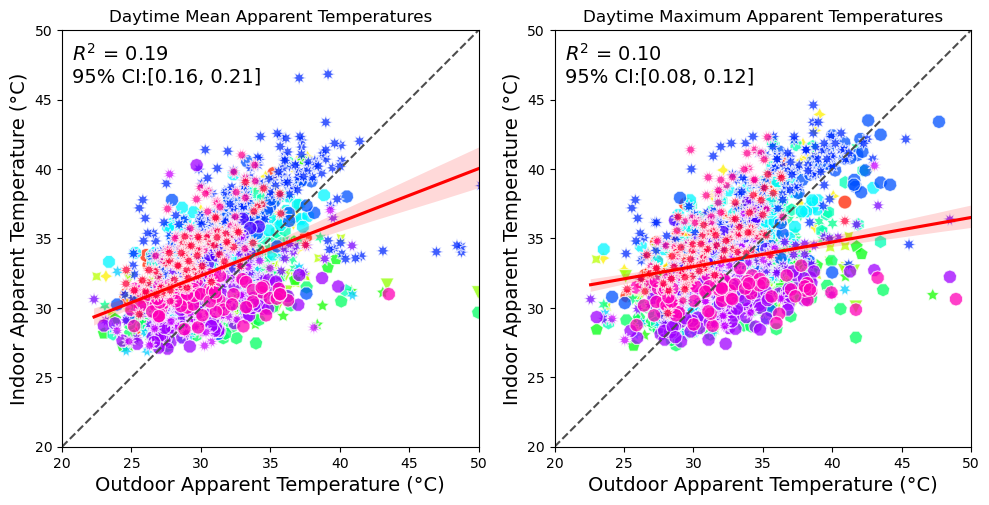

In [24]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

def annotate_fit(x, y, ax):
    # Drop NaN values
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    X = sm.add_constant(df['x'])
    model = sm.OLS(df['y'], X).fit()
    a, b = model.params['const'], model.params['x']
    r2 = model.rsquared
    
    # Calculate the confidence interval for R using Pingouin
    ci = pg.corr(x=df['x'], y=df['y']).loc['pearson', 'CI95%']
    # Square the CI values to get the CI for R^2
    ci_r2 = [value**2 for value in ci]
    
    ax.annotate(f'$R^2$ = {r2:.2f}\n95% CI:[{ci_r2[0]:.2f}, {ci_r2[1]:.2f}]', 
                xy=(0.025, 0.875), xycoords='axes fraction', fontsize=14)

# Assuming merged_df and ndvi_values are already loaded as described
# Convert 'site_id' to string if not already (in both dataframes)
merged_df['site_id'] = merged_df['site_id'].astype(str)


# Assuming your dataframe has a datetime column named "timestamp"
merged_df['Date'] = merged_df['Date/Time'].dt.date

# Step 1: Day-Level Aggregation with 'site_type_outdoor'
day_level = merged_df.groupby(['sensor_id_indoor_temp', 'Date', 'Day/night']).agg(
    daily_mean_indoor=('Indoor_Heat_Index', 'mean'),
    daily_mean_outdoor=('Outdoor_Heat_Index', 'mean'),
    daily_max_indoor=('Indoor_Heat_Index', 'max'),
    daily_max_outdoor=('Outdoor_Heat_Index', 'max'),
).reset_index()

# Step 2: Sensor-Level Aggregation
aggregated_data = day_level.groupby(['sensor_id_indoor_temp', 'Day/night']).agg(
    average_daily_mean_indoor=('daily_mean_indoor', 'mean'),
    average_daily_mean_outdoor=('daily_mean_outdoor', 'mean'),
    average_daily_max_indoor=('daily_max_indoor', 'mean'),
    average_daily_max_outdoor=('daily_max_outdoor', 'mean'),
).reset_index()

# Choose either 'day_level' or 'aggregated_data' for analysis
analysis_level = 'day_level'  # Set to either 'day' or 'aggregated'
# analysis_level = 'aggregated'  # Set to either 'day' or 'aggregated'

if analysis_level == 'day_level':
    analysis_frame = day_level
    axis_prefix = 'Daily'
elif analysis_level == 'aggregated':
    analysis_frame = aggregated_data
    axis_prefix = 'Average Daily'

day_night = 'Day'  # Change as needed
# day_night = 'Night'  # Change as needed

plt.figure(figsize=(10, 10))  # Adjusted for a square plot

# Helper function to find the common limits
def find_common_limits(series1, series2, upper_bound=None):
    combined = pd.concat([series1, series2], ignore_index=True)
    lower = combined.min()
    upper = combined.max()
    if upper_bound is not None:
        upper = min(upper, upper_bound)
    return lower, upper
    
# Find the common limits for mean temperatures
# mean_limits = find_common_limits(analysis_frame[axis_prefix.lower().replace(' ','_')+'_mean_outdoor'], 
#                                  analysis_frame[axis_prefix.lower().replace(' ','_')+'_mean_indoor'])

mean_limits = 20, 50
# mean_limits = 27.5, 40

# Generate a vivid colormap
vivid_colors = sns.color_palette("hsv", len(analysis_frame['sensor_id_indoor_temp'].unique()))

# Mean average temperatures - modified to color by sensor_id_indoor_temp
ax1 = plt.subplot(121)
sns.scatterplot(
    data=analysis_frame[analysis_frame['Day/night'] == day_night], 
    x=axis_prefix.lower().replace(' ','_')+'_mean_outdoor', 
    y=axis_prefix.lower().replace(' ','_')+'_mean_indoor',
    hue='sensor_id_indoor_temp',  # Color by sensor_id_indoor_temp
    style='sensor_id_indoor_temp',  # Different styles for different sensor_id_indoor_temp
    palette=vivid_colors,  # Apply vivid colormap
    alpha=0.75,  # Increased alpha for better visibility
    s=100,  # Increased point size
    ax=ax1, 
    legend=False
)

sns.regplot(data=analysis_frame[analysis_frame['Day/night'] == day_night], 
            x=axis_prefix.lower().replace(' ','_')+'_mean_outdoor', 
            y=axis_prefix.lower().replace(' ','_')+'_mean_indoor', 
            ax=ax1, 
            scatter=False,
            line_kws={'color': 'red'}, 
            ci=95)
ax1.set_xlim(mean_limits)
ax1.set_ylim(mean_limits)
ax1.set_aspect('equal')
ax1.plot(mean_limits, mean_limits, ls="--", c=".3")  # x=y line
ax1.set_title(f'{day_night}time Mean Apparent Temperatures')
ax1.set_ylabel('Indoor Apparent Temperature (°C)', fontsize=14)
ax1.set_xlabel('Outdoor Apparent Temperature (°C)', fontsize=14)
annotate_fit(analysis_frame[axis_prefix.lower().replace(' ','_')+'_mean_outdoor'], analysis_frame[axis_prefix.lower().replace(' ','_')+'_mean_indoor'], ax1)

if day_night == 'Day':
    # max_limits = find_common_limits(analysis_frame[axis_prefix.lower().replace(' ','_')+'_max_outdoor'], 
    #                                 analysis_frame[axis_prefix.lower().replace(' ','_')+'_max_indoor'],
    #                                 upper_bound=50)  # Set upper bound to 50

    max_limits = mean_limits
    
    # Mean maximum temperatures
    ax2 = plt.subplot(122)
    sns.scatterplot(data=analysis_frame[analysis_frame['Day/night'] == day_night], 
                x=axis_prefix.lower().replace(' ','_')+'_max_outdoor', 
                y=axis_prefix.lower().replace(' ','_')+'_max_indoor',
                hue='sensor_id_indoor_temp',  # Color by sensor_id_indoor_temp
                style='sensor_id_indoor_temp',  # Different styles for different sensor_id_indoor_temp
                palette=vivid_colors,  # Apply vivid colormap
                alpha=0.75,  # Increased alpha for better visibility
                s=100,  # Increased point size
                ax=ax2,
                legend=False)
    
    sns.regplot(data=analysis_frame[analysis_frame['Day/night'] == day_night], 
                x=axis_prefix.lower().replace(' ','_')+'_max_outdoor', 
                y=axis_prefix.lower().replace(' ','_')+'_max_indoor', 
                ax=ax2, 
                scatter=False,
                line_kws={'color': 'red'}, 
                ci=95)
    ax2.set_xlim(max_limits)
    ax2.set_ylim(max_limits)
    ax2.set_aspect('equal')
    ax2.plot(max_limits, max_limits, ls="--", c=".3")  # x=y line
    ax2.set_title(f'{day_night}time Maximum Apparent Temperatures')
    ax2.set_ylabel('Indoor Apparent Temperature (°C)', fontsize=14)
    ax2.set_xlabel('Outdoor Apparent Temperature (°C)', fontsize=14)
    annotate_fit(analysis_frame[axis_prefix.lower().replace(' ','_')+'_max_outdoor'], analysis_frame[axis_prefix.lower().replace(' ','_')+'_max_indoor'], ax2)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=-0.25)  # Provide space at the bottom for the legend

plt.savefig(f"{analysis_level}_{day_night}_correlation_indoor_outdoor_sensor_style.png", bbox_inches='tight')


/tmp/ipykernel_40913/4071109438.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Date'] = filtered_df['Date/Time'].dt.date


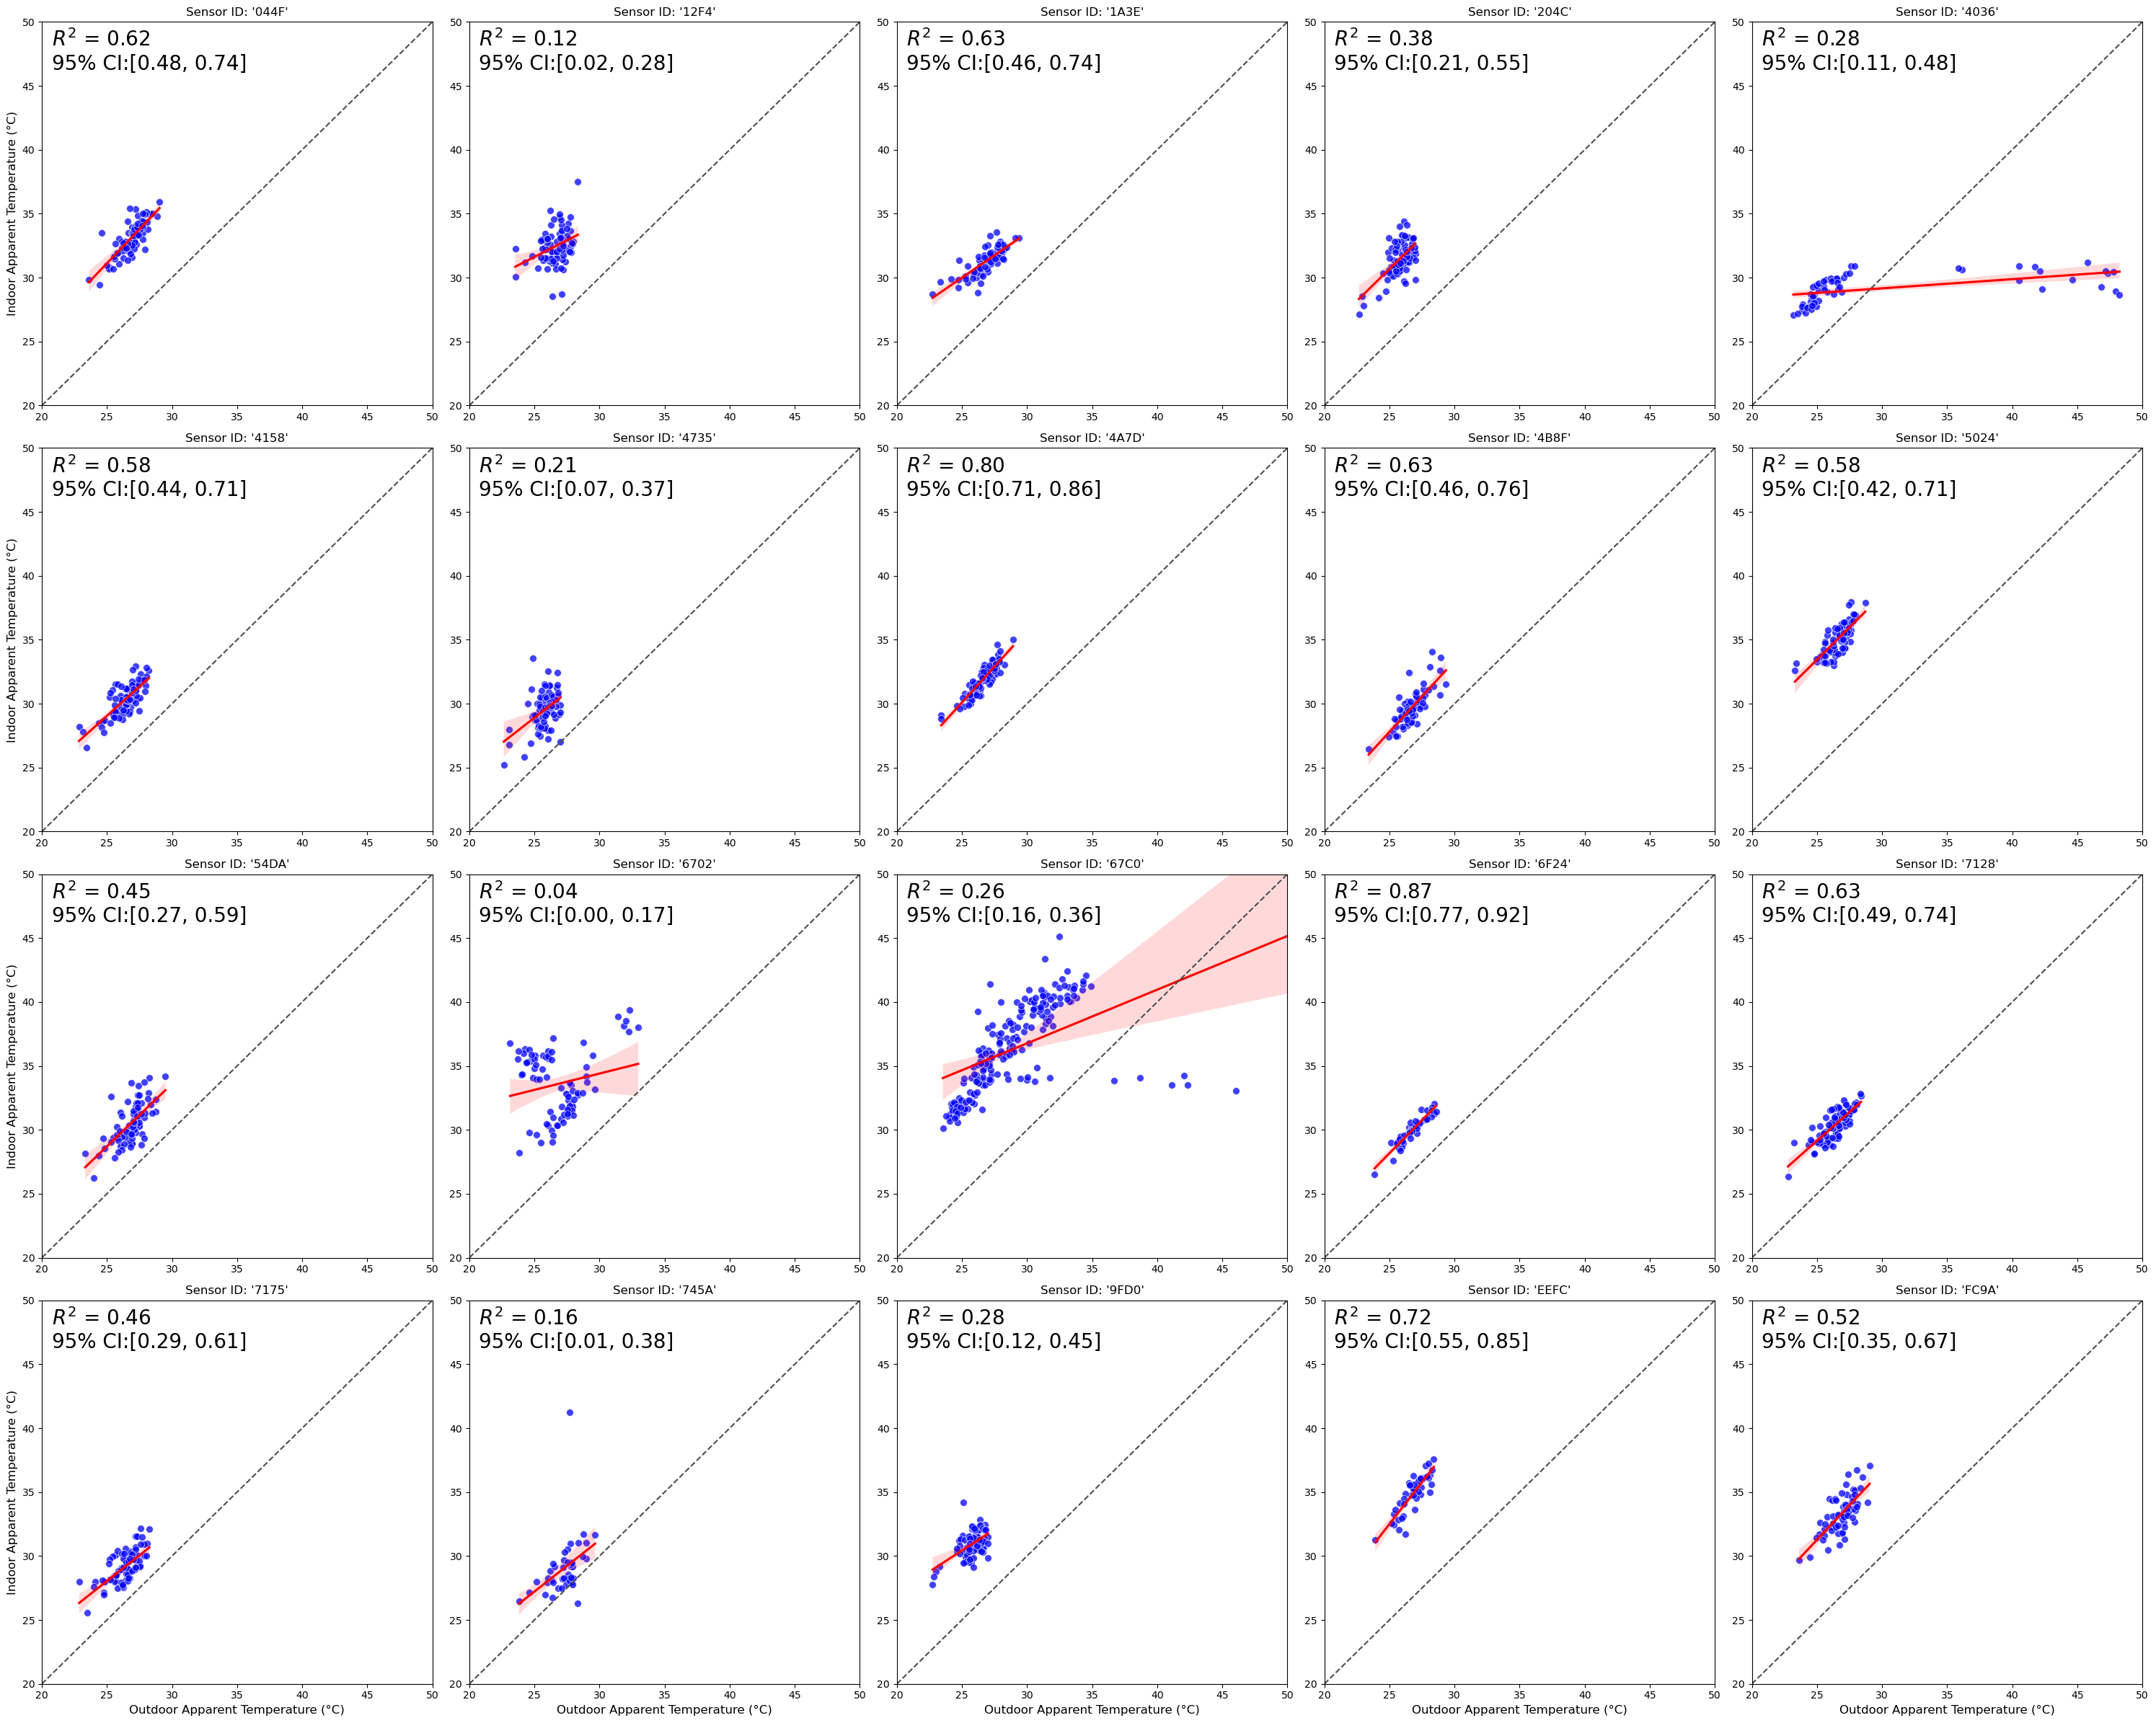

In [8]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

def annotate_fit(x, y, ax):
    # Drop NaN values
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    X = sm.add_constant(df['x'])
    model = sm.OLS(df['y'], X).fit()
    a, b = model.params['const'], model.params['x']
    r2 = model.rsquared
    
    # Calculate the confidence interval for R using Pingouin
    ci = pg.corr(x=df['x'], y=df['y']).loc['pearson', 'CI95%']
    # Square the CI values to get the CI for R^2
    ci_r2 = [value**2 for value in ci]
    
    ax.annotate(f'$R^2$ = {r2:.2f}\n95% CI:[{ci_r2[0]:.2f}, {ci_r2[1]:.2f}]', 
                xy=(0.025, 0.875), xycoords='axes fraction', fontsize=20)

# Assuming merged_df and ndvi_values are already loaded as described
# Convert 'site_id' to string if not already (in both dataframes)
merged_df['site_id'] = merged_df['site_id'].astype(str)

# Filter the data to include only those sites with more than one valid pair of data points
valid_sites = merged_df.dropna(subset=['Indoor_Heat_Index', 'Outdoor_Heat_Index']).groupby('sensor_id_indoor_temp').filter(lambda x: len(x) > 1)['sensor_id_indoor_temp'].unique()
filtered_df = merged_df[merged_df['sensor_id_indoor_temp'].isin(valid_sites)]

# Assuming your dataframe has a datetime column named "timestamp"
filtered_df['Date'] = filtered_df['Date/Time'].dt.date

# Step 1: Day-Level Aggregation with 'site_type_outdoor'
day_level = filtered_df.groupby(['sensor_id_indoor_temp', 'Date', 'Day/night']).agg(
    daily_mean_indoor=('Indoor_Heat_Index', 'mean'),
    daily_mean_outdoor=('Outdoor_Heat_Index', 'mean'),
    daily_max_indoor=('Indoor_Heat_Index', 'max'),
    daily_max_outdoor=('Outdoor_Heat_Index', 'max'),
).reset_index()

# Step 2: Sensor-Level Aggregation
aggregated_data = day_level.groupby(['sensor_id_indoor_temp', 'Day/night']).agg(
    average_daily_mean_indoor=('daily_mean_indoor', 'mean'),
    average_daily_mean_outdoor=('daily_mean_outdoor', 'mean'),
    average_daily_max_indoor=('daily_max_indoor', 'mean'),
    average_daily_max_outdoor=('daily_max_outdoor', 'mean'),
).reset_index()

# Choose either 'day_level' or 'aggregated_data' for analysis
analysis_level = 'day_level'  # Set to either 'day' or 'aggregated'
# analysis_level = 'aggregated'  # Set to either 'day' or 'aggregated'

if analysis_level == 'day_level':
    analysis_frame = day_level
    axis_prefix = 'Daily'
elif analysis_level == 'aggregated':
    analysis_frame = aggregated_data
    axis_prefix = 'Average Daily'

# Choose the time of day and metric for plotting
# day_night = 'Day'  # Change as needed
day_night = 'Night'  # Change as needed

metric = 'mean'  # Choose between 'mean' and 'max'

# Create a 4x5 grid of subplots
fig, axes = plt.subplots(4, 5, figsize=(30, 24))  # Adjust size for better visibility
axes = axes.flatten()

# Get unique sensor IDs
unique_sensors = analysis_frame['sensor_id_indoor_temp'].unique()

# Iterate through each sensor and create a subplot
for i, sensor_id in enumerate(unique_sensors):
    ax = axes[i]
    sensor_data = analysis_frame[(analysis_frame['sensor_id_indoor_temp'] == sensor_id) & (analysis_frame['Day/night'] == day_night)]
    
    if metric == 'mean':
        sns.scatterplot(
            data=sensor_data,
            x=f'{axis_prefix.lower().replace(" ", "_")}_mean_outdoor',
            y=f'{axis_prefix.lower().replace(" ", "_")}_mean_indoor',
            ax=ax,
            color='blue',  # Use a single color for points
            alpha=0.75,
            s=50  # Adjust point size as needed
        )
        sns.regplot(
            data=sensor_data,
            x=f'{axis_prefix.lower().replace(" ", "_")}_mean_outdoor',
            y=f'{axis_prefix.lower().replace(" ", "_")}_mean_indoor',
            ax=ax,
            scatter=False,
            line_kws={'color': 'red'},
            ci=95
        )
    elif metric == 'max':
        sns.scatterplot(
            data=sensor_data,
            x=f'{axis_prefix.lower().replace(" ", "_")}_max_outdoor',
            y=f'{axis_prefix.lower().replace(" ", "_")}_max_indoor',
            ax=ax,
            color='blue',  # Use a single color for points
            alpha=0.75,
            s=50  # Adjust point size as needed
        )
        sns.regplot(
            data=sensor_data,
            x=f'{axis_prefix.lower().replace(" ", "_")}_max_outdoor',
            y=f'{axis_prefix.lower().replace(" ", "_")}_max_indoor',
            ax=ax,
            scatter=False,
            line_kws={'color': 'red'},
            ci=95
        )
    
    ax.set_title(f'Sensor ID: {sensor_id}')
    ax.set_xlim(20, 50)  # Adjust x-axis limits as needed
    ax.set_ylim(20, 50)  # Adjust y-axis limits as needed
    ax.plot([20, 50], [20, 50], ls="--", c=".3")  # x=y line

    # Annotate the fit
    annotate_fit(sensor_data[f'{axis_prefix.lower().replace(" ", "_")}_mean_outdoor' if metric == 'mean' else f'{axis_prefix.lower().replace(" ", "_")}_max_outdoor'], 
                 sensor_data[f'{axis_prefix.lower().replace(" ", "_")}_mean_indoor' if metric == 'mean' else f'{axis_prefix.lower().replace(" ", "_")}_max_indoor'], ax)
    if i % 5 == 0: 
        ax.set_ylabel('Indoor Apparent Temperature (°C)', fontsize=12)
    if i >= 15:
        ax.set_xlabel('Outdoor Apparent Temperature (°C)', fontsize=12)
    
    # Remove innermost labels
    if i % 5 != 0:
        ax.set_ylabel('')
    if i < 15:
        ax.set_xlabel('')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(f"{analysis_level}_{day_night}_{metric}_correlation_indoor_outdoor_grid.png", bbox_inches='tight')
plt.show()

/tmp/ipykernel_120/35745831.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Date'] = filtered_df['Date/Time'].dt.date
/tmp/ipykernel_120/35745831.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=r2_df, x='condition', y='r2', palette='Set2')


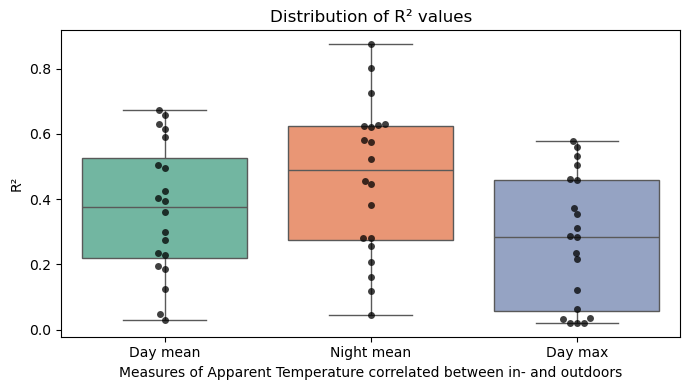

In [46]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_r2(x, y):
    # Drop NaN values
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(df) < 2:
        return None
    X = sm.add_constant(df['x'])
    model = sm.OLS(df['y'], X).fit()
    return model.rsquared

# Assuming merged_df is already loaded and filtered as described
# Convert 'site_id' to string if not already (in both dataframes)
merged_df['site_id'] = merged_df['site_id'].astype(str)

# Filter the data to include only those sites with more than one valid pair of data points
valid_sites = merged_df.dropna(subset=['Indoor_Heat_Index', 'Outdoor_Heat_Index']).groupby('sensor_id_indoor_temp').filter(lambda x: len(x) > 1)['sensor_id_indoor_temp'].unique()
filtered_df = merged_df[merged_df['sensor_id_indoor_temp'].isin(valid_sites)]

# Assuming your dataframe has a datetime column named "timestamp"
filtered_df['Date'] = filtered_df['Date/Time'].dt.date

# Step 1: Day-Level Aggregation with 'site_type_outdoor'
day_level = filtered_df.groupby(['sensor_id_indoor_temp', 'Date', 'Day/night']).agg(
    daily_mean_indoor=('Indoor_Heat_Index', 'mean'),
    daily_mean_outdoor=('Outdoor_Heat_Index', 'mean'),
    daily_max_indoor=('Indoor_Heat_Index', 'max'),
    daily_max_outdoor=('Outdoor_Heat_Index', 'max'),
).reset_index()

# Step 2: Sensor-Level Aggregation
aggregated_data = day_level.groupby(['sensor_id_indoor_temp', 'Day/night']).agg(
    average_daily_mean_indoor=('daily_mean_indoor', 'mean'),
    average_daily_mean_outdoor=('daily_mean_outdoor', 'mean'),
    average_daily_max_indoor=('daily_max_indoor', 'mean'),
    average_daily_max_outdoor=('daily_max_outdoor', 'mean'),
).reset_index()

# Prepare data for R² calculation
analysis_frame = day_level  # Use day_level for detailed analysis
axis_prefix = 'Daily'

# Function to gather R² values for a specific condition
def gather_r2_values(day_night, metric):
    r2_values = []
    for sensor_id in analysis_frame['sensor_id_indoor_temp'].unique():
        sensor_data = analysis_frame[(analysis_frame['sensor_id_indoor_temp'] == sensor_id) & (analysis_frame['Day/night'] == day_night)]
        
        if metric == 'mean':
            r2 = calculate_r2(sensor_data[f'{axis_prefix.lower().replace(" ", "_")}_mean_outdoor'], sensor_data[f'{axis_prefix.lower().replace(" ", "_")}_mean_indoor'])
        elif metric == 'max':
            r2 = calculate_r2(sensor_data[f'{axis_prefix.lower().replace(" ", "_")}_max_outdoor'], sensor_data[f'{axis_prefix.lower().replace(" ", "_")}_max_indoor'])
        
        if r2 is not None:
            r2_values.append({'sensor_id': sensor_id, 'r2': r2, 'condition': f'{day_night} {metric}'})
    return r2_values

# Gather R² values for day mean, night mean, and day max
r2_day_mean = gather_r2_values('Day', 'mean')
r2_night_mean = gather_r2_values('Night', 'mean')
r2_day_max = gather_r2_values('Day', 'max')

# Combine all R² values into a single DataFrame
r2_df = pd.DataFrame(r2_day_mean + r2_night_mean + r2_day_max)

# Plot the distribution of R² values
plt.figure(figsize=(7, 4))
sns.boxplot(data=r2_df, x='condition', y='r2', palette='Set2')
sns.swarmplot(data=r2_df, x='condition', y='r2', color='black', alpha=0.75)
plt.title('Distribution of R² values')
plt.xlabel('Measures of Apparent Temperature correlated between in- and outdoors')
plt.ylabel('R²')

plt.tight_layout()
plt.savefig("r2_distribution_conditions.png", bbox_inches='tight')
plt.show()


In [16]:
merged_df.columns

Index(['Unnamed: 0_outdoor', 'Date/Time', 'point_id_indoor_temp',
       'Unit_x_outdoor', 'Value_temp_outdoor', 'sensor_id_indoor_temp',
       'site_id_x', 'filename_x_outdoor', 'hh_id_x', 'hh_notes_x',
       ...
       'pop_dens_cat_y_indoor', 'ndvi_cat_y_indoor', 'Hour_y_indoor',
       'Outdoor_Heat_Index', 'Hour_indoor', 'heat_diff', 'Day/night',
       'mean_ndvi', 'mean_ndbi', 'Date'],
      dtype='object', length=164)

In [10]:
# Assuming your dataframe has a datetime column named "timestamp"
# filtered_df['Date'] = filtered_df['Date/Time'].dt.date

# Step 1: Day-Level Aggregation with 'site_type_outdoor'
day_level_outdoor = merged_df.groupby(['site_id', 'Date', 'Day/night']).agg(
    daily_mean_outdoor_temp=('Value_temp_outdoor', 'mean'),
    daily_mean_outdoor_hum=('Value_hum_outdoor', 'mean'),
    # daily_mean_indoor_temp=('Value_temp_indoor', 'mean'),
    # daily_mean_indoor_hum=('Value_hum_indoor', 'mean'),
    mean_ndvi=('mean_ndvi', 'first'),  # Assuming each sensor_id, Date, Day/night combo has a single site type
    mean_ndbi=('mean_ndbi', 'first'),
    heat_index = ('Outdoor_Heat_Index','mean')# Assuming each sensor_id, Date, Day/night combo has a single site type
).reset_index()

day_level_indoor = merged_df.groupby(['sensor_id_indoor_temp', 'Date', 'Day/night']).agg(
    daily_mean_indoor_temp=('Value_temp_indoor', 'mean'),
    daily_mean_indoor_hum=('Value_hum_indoor', 'mean'),
    mean_ndvi=('mean_ndvi', 'first'),  # Assuming each sensor_id, Date, Day/night combo has a single site type
    mean_ndbi=('mean_ndbi', 'first'),
    heat_index = ('Indoor_Heat_Index','mean')# Assuming each sensor_id, Date, Day/night combo has a single site type
).reset_index()

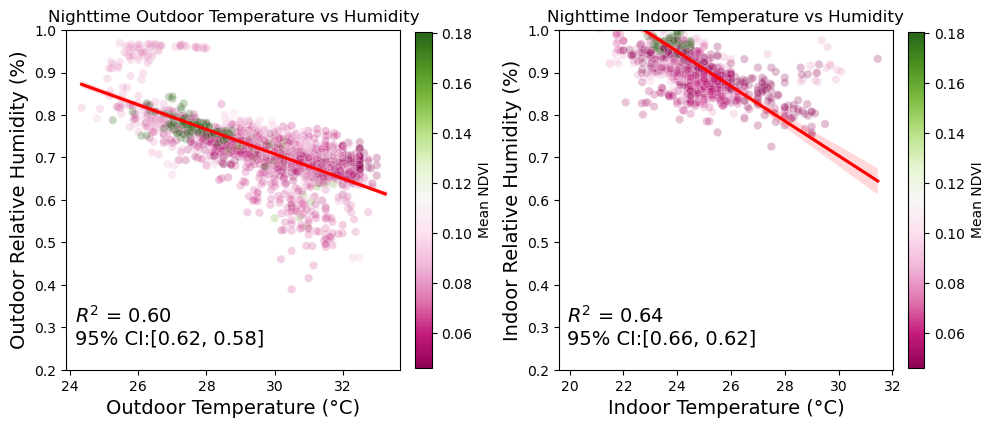

In [19]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

def annotate_fit(x, y, ax):
    # Drop NaN values
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    X = sm.add_constant(df['x'])
    model = sm.OLS(df['y'], X).fit()
    a, b = model.params['const'], model.params['x']
    r2 = model.rsquared
    
    # Calculate the confidence interval for R using Pingouin
    ci = pg.corr(x=df['x'], y=df['y']).loc['pearson', 'CI95%']
    # Square the CI values to get the CI for R^2
    ci_r2 = [value**2 for value in ci]
    
    # ax.annotate(f'Y = {a:.2f} + {b:.2f}X\n$R^2$ = {r2:.2f}, 95% CI: [{ci_r2[0]:.2f}, {ci_r2[1]:.2f}]', 
    #             xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14)
    ax.annotate(f'$R^2$ = {r2:.2f}\n95% CI:[{ci_r2[0]:.2f}, {ci_r2[1]:.2f}]', 
                xy=(0.025, 0.075), xycoords='axes fraction', fontsize=14)

# Choose either 'day_level' or 'aggregated_data' for analysis
analysis_level = 'day_level'  # Set to either 'day' or 'aggregated'

if analysis_level == 'day_level':
    analysis_frame_outdoor = day_level_outdoor
    analysis_frame_indoor = day_level_indoor
    axis_prefix = 'Daily'
elif analysis_level == 'aggregated':
    analysis_frame = aggregated_data
    axis_prefix = 'Average Daily'

# day_night = 'Day'  # Change as needed
day_night = 'Night'  # Change as needed

# Sort the analysis_frame by 'mean_ndvi'
analysis_frame = analysis_frame.sort_values('mean_ndvi')

plt.figure(figsize=(10, 3))  # Adjusted for a square plot

# # Custom colormap for NDVI
# cmap = sns.light_palette("green", as_cmap=True)


# Mean average temperatures - modified to color by mean_ndvi
ax1 = plt.subplot(121)
sns.scatterplot(
    data=analysis_frame_outdoor[analysis_frame_outdoor['Day/night'] == day_night], 
    x=axis_prefix.lower().replace(' ','_')+'_mean_outdoor_temp', 
    y=axis_prefix.lower().replace(' ','_')+'_mean_outdoor_hum',
    hue='mean_ndvi',  # Color by mean NDVI value
    # palette=cmap,
    palette='PiYG',
    alpha=0.25,
    legend=False,  # Temporarily disable legend
    ax=ax1
)

# Add colorbar for NDVI
smc = plt.cm.ScalarMappable(cmap='PiYG', norm=plt.Normalize(vmin=analysis_frame_outdoor['mean_ndvi'].min(), vmax=analysis_frame_outdoor['mean_ndvi'].max()))
smc.set_array([])
cbar = plt.colorbar(smc, ax=ax1,fraction=0.046, pad=0.04)
cbar.set_label('Mean NDVI')

sns.regplot(data=analysis_frame_outdoor[analysis_frame_outdoor['Day/night'] == day_night], 
            x=axis_prefix.lower().replace(' ','_')+'_mean_outdoor_temp', 
            y=axis_prefix.lower().replace(' ','_')+'_mean_outdoor_hum', 
            ax=ax1, 
            scatter = False,
            # scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'}, 
            ci=95)
# ax1.set_xlim(mean_limits)
ax1.set_ylim(0.2,1)
# ax1.set_aspect('equal')
# ax1.plot(mean_limits, mean_limits, ls="--", c=".3")  # x=y line
ax1.set_title(f'{day_night}time Outdoor Temperature vs Humidity')
ax1.set_ylabel('Outdoor Relative Humidity (%)', fontsize = 14)
ax1.set_xlabel('Outdoor Temperature (°C)', fontsize = 14)
annotate_fit(analysis_frame_outdoor[axis_prefix.lower().replace(' ','_')+'_mean_outdoor_temp'], analysis_frame_outdoor[axis_prefix.lower().replace(' ','_')+'_mean_outdoor_hum'], ax1)

# max_limits = find_common_limits(analysis_frame[axis_prefix.lower().replace(' ','_')+'_max_outdoor'],     #                                 analysis_frame[axis_prefix.lower().replace(' ','_')+'_max_indoor'],
#                                 upper_bound=50)  # Set upper bound to 50

max_limits = mean_limits

# Mean maximum temperatures
ax2 = plt.subplot(122)
sns.scatterplot(data=analysis_frame_indoor[analysis_frame_indoor['Day/night'] == day_night], 
            x=axis_prefix.lower().replace(' ','_')+'_mean_indoor_temp', 
            y=axis_prefix.lower().replace(' ','_')+'_mean_indoor_hum',
            hue='mean_ndvi',  # Color by mean NDVI value
            # palette=cmap,
            palette='PiYG',
            alpha=0.25,
            legend=False,  # Temporarily disable legend
            ax=ax2)
# Add colorbar for NDVI
smc2 = plt.cm.ScalarMappable(cmap='PiYG', norm=plt.Normalize(vmin=analysis_frame_indoor['mean_ndvi'].min(), vmax=analysis_frame_indoor['mean_ndvi'].max()))
smc2.set_array([])
cbar2 = plt.colorbar(smc2, ax=ax2,fraction=0.046, pad=0.04)
cbar2.set_label('Mean NDVI')
sns.regplot(data=analysis_frame_indoor[analysis_frame_indoor['Day/night'] == day_night], 
            x=axis_prefix.lower().replace(' ','_')+'_mean_indoor_temp', 
            y=axis_prefix.lower().replace(' ','_')+'_mean_indoor_hum', 
            ax=ax2, 
            # scatter_kws={'alpha': 0.5}, 
            scatter = False,
            line_kws={'color': 'red'}, 
            ci=95)
# ax2.set_xlim(max_limits)
ax2.set_ylim(0.2,1)
# ax2.set_aspect('equal')
# ax2.plot(max_limits, max_limits, ls="--", c=".3")  # x=y line
ax2.set_title(f'{day_night}time Indoor Temperature vs Humidity')
ax2.set_ylabel('Indoor Relative Humidity (%)', fontsize = 14)
ax2.set_xlabel('Indoor Temperature (°C)', fontsize = 14)
annotate_fit(analysis_frame_indoor[axis_prefix.lower().replace(' ','_')+'_mean_indoor_temp'], analysis_frame_indoor[axis_prefix.lower().replace(' ','_')+'_mean_indoor_hum'], ax2)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=-0.25)  # Provide space at the bottom for the legend

# plt.show()
plt.savefig(f"{analysis_level}_{day_night}_correlation_indoor_outdoor_ndvi_hum_temp.png", bbox_inches='tight')


In [ ]:
day_level

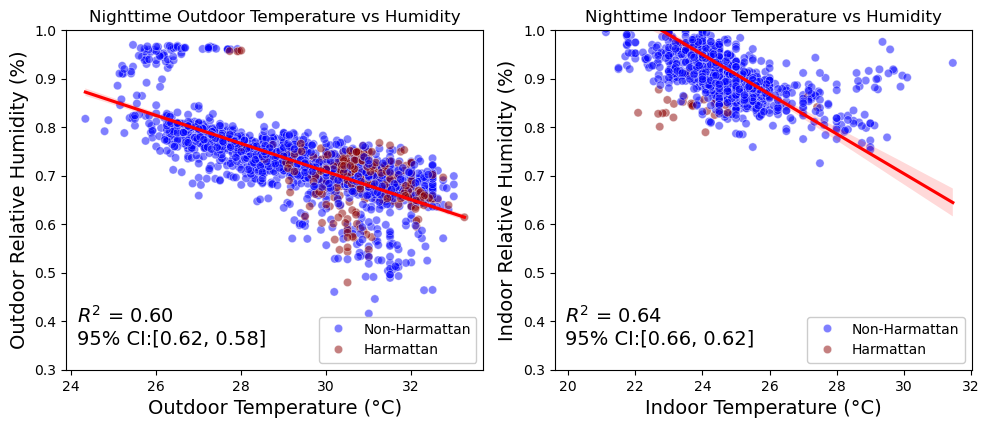

In [19]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

def is_harmattan(date):
    return 11 <= date.month <= 3 or date.month == 11

def annotate_fit(x, y, ax):
# Drop NaN values
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    X = sm.add_constant(df['x'])
    model = sm.OLS(df['y'], X).fit()
    a, b = model.params['const'], model.params['x']
    r2 = model.rsquared
    
    # Calculate the confidence interval for R using Pingouin
    ci = pg.corr(x=df['x'], y=df['y']).loc['pearson', 'CI95%']
    # Square the CI values to get the CI for R^2
    ci_r2 = [value**2 for value in ci]
    
    # ax.annotate(f'Y = {a:.2f} + {b:.2f}X\n$R^2$ = {r2:.2f}, 95% CI: [{ci_r2[0]:.2f}, {ci_r2[1]:.2f}]', 
    #             xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14)
    ax.annotate(f'$R^2$ = {r2:.2f}\n95% CI:[{ci_r2[0]:.2f}, {ci_r2[1]:.2f}]', 
                xy=(0.025, 0.075), xycoords='axes fraction', fontsize=14)
    
# Choose either 'day_level' or 'aggregated_data' for analysis
analysis_level = 'day_level'  # Set to either 'day' or 'aggregated'

if analysis_level == 'day_level':
    analysis_frame_outdoor = day_level_outdoor
    analysis_frame_indoor = day_level_indoor
    axis_prefix = 'Daily'
elif analysis_level == 'aggregated':
    analysis_frame = aggregated_data
    axis_prefix = 'Average Daily'

# Apply the is_harmattan function to create the 'is_harmattan' column
analysis_frame_outdoor['is_harmattan'] = analysis_frame_outdoor['Date'].map(is_harmattan)
analysis_frame_indoor['is_harmattan'] = analysis_frame_indoor['Date'].map(is_harmattan)

day_night = 'Night'  # Change as needed

plt.figure(figsize=(10, 3))  # Adjusted for a square plot

# Mean average temperatures - modified to color by is_harmattan
ax1 = plt.subplot(121)
sns.scatterplot(
    data=analysis_frame_outdoor[analysis_frame_outdoor['Day/night'] == day_night], 
    x=axis_prefix.lower().replace(' ','_')+'_mean_outdoor_temp', 
    y=axis_prefix.lower().replace(' ','_')+'_mean_outdoor_hum',
    hue='is_harmattan',  # Color by Harmattan
    palette=['blue', 'darkred'],  # Non-Harmattan: blue, Harmattan: darkred
    alpha=0.5,
    ax=ax1
)

sns.regplot(data=analysis_frame_outdoor[analysis_frame_outdoor['Day/night'] == day_night], 
            x=axis_prefix.lower().replace(' ','_')+'_mean_outdoor_temp', 
            y=axis_prefix.lower().replace(' ','_')+'_mean_outdoor_hum', 
            ax=ax1, 
            scatter = False,
            line_kws={'color': 'red'}, 
            ci=95)

ax1.set_ylim(0.3,1)
ax1.set_title(f'{day_night}time Outdoor Temperature vs Humidity')
ax1.set_ylabel('Outdoor Relative Humidity (%)', fontsize = 14)
ax1.set_xlabel('Outdoor Temperature (°C)', fontsize = 14)
annotate_fit(analysis_frame_outdoor[axis_prefix.lower().replace(' ','_')+'_mean_outdoor_temp'], analysis_frame_outdoor[axis_prefix.lower().replace(' ','_')+'_mean_outdoor_hum'], ax1)

# Rename legend labels
handles, labels = ax1.get_legend_handles_labels()
labels = ['Non-Harmattan', 'Harmattan']
ax1.legend(handles, labels, title='', loc='lower right', framealpha=1)

# Mean maximum temperatures - modified to color by is_harmattan
ax2 = plt.subplot(122)
sns.scatterplot(data=analysis_frame_indoor[analysis_frame_indoor['Day/night'] == day_night], 
            x=axis_prefix.lower().replace(' ','_')+'_mean_indoor_temp', 
            y=axis_prefix.lower().replace(' ','_')+'_mean_indoor_hum',
            hue='is_harmattan',  # Color by Harmattan
            palette=['blue', 'darkred'],  # Non-Harmattan: blue, Harmattan: darkred
            alpha=0.5,
            ax=ax2)

sns.regplot(data=analysis_frame_indoor[analysis_frame_indoor['Day/night'] == day_night], 
            x=axis_prefix.lower().replace(' ','_')+'_mean_indoor_temp', 
            y=axis_prefix.lower().replace(' ','_')+'_mean_indoor_hum', 
            ax=ax2, 
            scatter = False,
            line_kws={'color': 'red'}, 
            ci=95)

ax2.set_ylim(0.3,1)
ax2.set_title(f'{day_night}time Indoor Temperature vs Humidity')
ax2.set_ylabel('Indoor Relative Humidity (%)', fontsize = 14)
ax2.set_xlabel('Indoor Temperature (°C)', fontsize = 14)
annotate_fit(analysis_frame_indoor[axis_prefix.lower().replace(' ','_')+'_mean_indoor_temp'], analysis_frame_indoor[axis_prefix.lower().replace(' ','_')+'_mean_indoor_hum'], ax2)

# Rename legend labels
handles, labels = ax2.get_legend_handles_labels()
labels = ['Non-Harmattan', 'Harmattan']
ax2.legend(handles, labels, title='', loc='lower right', framealpha=1)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=-0.25)  # Provide space at the bottom for the legend

plt.savefig(f"{analysis_level}_{day_night}_correlation_indoor_outdoor_harmattan_hum_temp.png", bbox_inches='tight')

In [14]:
# Define the hours for daytime and nighttime
daytime_hours = list(range(6, 18))
nighttime_hours = list(range(18, 24)) + list(range(0, 6))

# Extracting the date from the timestamp
outdoor_heat['Date'] = outdoor_heat.index.date

# For each site, for each day, calculate mean of daytime and nighttime heat indices, and max of daytime heat indices
daily_heat_metrics = outdoor_heat.groupby(['site_id', 'Date']).progress_apply(lambda group: pd.Series({
    'daily_avg_daytime_temperature': group[group['Hour'].isin(daytime_hours)]['Outdoor_Heat_Index'].mean(),
    'daily_avg_nighttime_temperature': group[group['Hour'].isin(nighttime_hours)]['Outdoor_Heat_Index'].mean(),
    'daily_max_daytime_temperature': group[group['Hour'].isin(daytime_hours)]['Outdoor_Heat_Index'].max()
}))

# Now, average these daily heat metrics over all days for each site
aggregated_heat_data = daily_heat_metrics.groupby('site_id').mean().reset_index()

# You don't need to merge distances here again if you already did it with temperature data, 
# unless you want this to be a standalone DataFrame.
# aggregated_heat_data = aggregated_heat_data.merge(outdoor_temp[['site_id', 'distance']].drop_duplicates(), on='site_id', how='left')
aggregated_heat_data.set_index('site_id', inplace=True)  # Set the site_id back as the index

# Sort the sites by the chosen method
sort_by_heat = 'daily_avg_daytime_temperature'  # or any other column you prefer
sorted_heat_sites = aggregated_heat_data.sort_values(sort_by_heat)


  0%|          | 0/2768 [00:00<?, ?it/s]

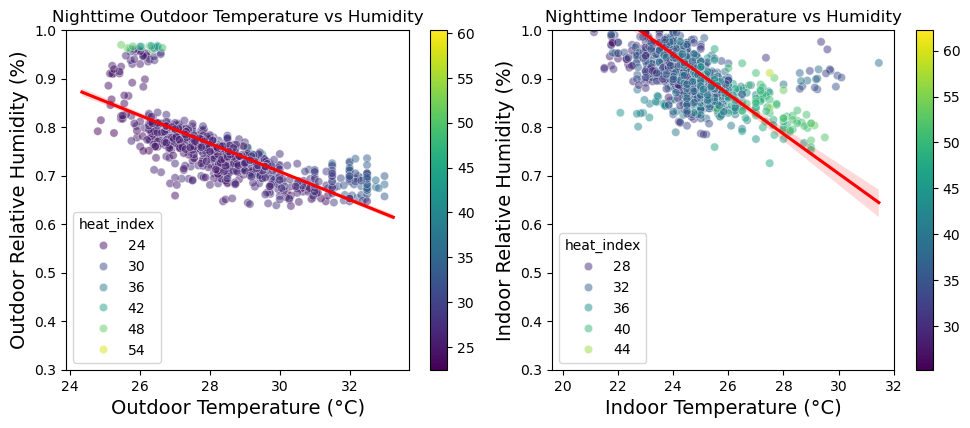

In [12]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

def annotate_fit(x, y, ax):
    # Drop NaN values
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    X = sm.add_constant(df['x'])
    model = sm.OLS(df['y'], X).fit()
    a, b = model.params['const'], model.params['x']
    r2 = model.rsquared
    
    # Calculate the confidence interval for R using Pingouin
    ci = pg.corr(x=df['x'], y=df['y']).loc['pearson', 'CI95%']
    # Square the CI values to get the CI for R^2
    ci_r2 = [value**2 for value in ci]
    
    ax.annotate(f'$R^2$ = {r2:.2f}\n95% CI:[{ci_r2[0]:.2f}, {ci_r2[1]:.2f}]', 
                xy=(0.025, 0.075), xycoords='axes fraction', fontsize=14)
    
# Choose either 'day_level' or 'aggregated_data' for analysis
analysis_level = 'day_level'  # Set to either 'day' or 'aggregated'

if analysis_level == 'day_level':
    analysis_frame_outdoor = day_level_outdoor
    analysis_frame_indoor = day_level_indoor
    axis_prefix = 'Daily'
elif analysis_level == 'aggregated':
    analysis_frame = aggregated_data
    axis_prefix = 'Average Daily'

# Calculate the heat index for both outdoor and indoor data
# Assuming heat_index is calculated and added to the dataframes
# analysis_frame_outdoor['heat_index'] = analysis_frame_outdoor['heat_index']  # Replace with actual calculation if needed
# analysis_frame_indoor['heat_index'] = analysis_frame_indoor['heat_index']    # Replace with actual calculation if needed

# Define the colormap variable
colormap = 'viridis'  # Change as needed

day_night = 'Night'  # Change as needed

plt.figure(figsize=(10, 3))  # Adjusted for a square plot

# Mean average temperatures - modified to color by heat_index
ax1 = plt.subplot(121)
scatter1 = sns.scatterplot(
    data=analysis_frame_outdoor[analysis_frame_outdoor['Day/night'] == day_night], 
    x=axis_prefix.lower().replace(' ','_')+'_mean_outdoor_temp', 
    y=axis_prefix.lower().replace(' ','_')+'_mean_outdoor_hum',
    hue='heat_index',  # Color by heat_index
    palette=colormap,  # Use the selected colormap
    alpha=0.5,
    ax=ax1
)

sns.regplot(data=analysis_frame_outdoor[analysis_frame_outdoor['Day/night'] == day_night], 
            x=axis_prefix.lower().replace(' ','_')+'_mean_outdoor_temp', 
            y=axis_prefix.lower().replace(' ','_')+'_mean_outdoor_hum', 
            ax=ax1, 
            scatter=False,
            line_kws={'color': 'red'}, 
            ci=95)

ax1.set_ylim(0.3, 1)
ax1.set_title(f'{day_night}time Outdoor Temperature vs Humidity')
ax1.set_ylabel('Outdoor Relative Humidity (%)', fontsize=14)
ax1.set_xlabel('Outdoor Temperature (°C)', fontsize=14)
# annotate_fit(analysis_frame_outdoor[axis_prefix.lower().replace(' ','_')+'_mean_outdoor_temp'], analysis_frame_outdoor[axis_prefix.lower().replace(' ','_')+'_mean_outdoor_hum'], ax1)

# Add color bar for the heat_index
norm = plt.Normalize(analysis_frame_outdoor['heat_index'].min(), analysis_frame_outdoor['heat_index'].max())
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
ax1.figure.colorbar(sm, ax=ax1)

# Mean maximum temperatures - modified to color by heat_index
ax2 = plt.subplot(122)
scatter2 = sns.scatterplot(data=analysis_frame_indoor[analysis_frame_indoor['Day/night'] == day_night], 
            x=axis_prefix.lower().replace(' ','_')+'_mean_indoor_temp', 
            y=axis_prefix.lower().replace(' ','_')+'_mean_indoor_hum',
            hue='heat_index',  # Color by heat_index
            palette=colormap,  # Use the selected colormap
            alpha=0.5,
            ax=ax2)

sns.regplot(data=analysis_frame_indoor[analysis_frame_indoor['Day/night'] == day_night], 
            x=axis_prefix.lower().replace(' ','_')+'_mean_indoor_temp', 
            y=axis_prefix.lower().replace(' ','_')+'_mean_indoor_hum', 
            ax=ax2, 
            scatter=False,
            line_kws={'color': 'red'}, 
            ci=95)

ax2.set_ylim(0.3, 1)
ax2.set_title(f'{day_night}time Indoor Temperature vs Humidity')
ax2.set_ylabel('Indoor Relative Humidity (%)', fontsize=14)
ax2.set_xlabel('Indoor Temperature (°C)', fontsize=14)
# annotate_fit(analysis_frame_indoor[axis_prefix.lower().replace(' ','_')+'_mean_indoor_temp'], analysis_frame_indoor[axis_prefix.lower().replace(' ','_')+'_mean_indoor_hum'], ax2)

# Add color bar for the heat_index
norm = plt.Normalize(analysis_frame_indoor['heat_index'].min(), analysis_frame_indoor['heat_index'].max())
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
ax2.figure.colorbar(sm, ax=ax2)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=-0.25)  # Provide space at the bottom for the legend

plt.savefig(f"paper_plots/{analysis_level}_{day_night}_correlation_indoor_outdoor_heat_index_hum_temp.png", bbox_inches='tight')


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

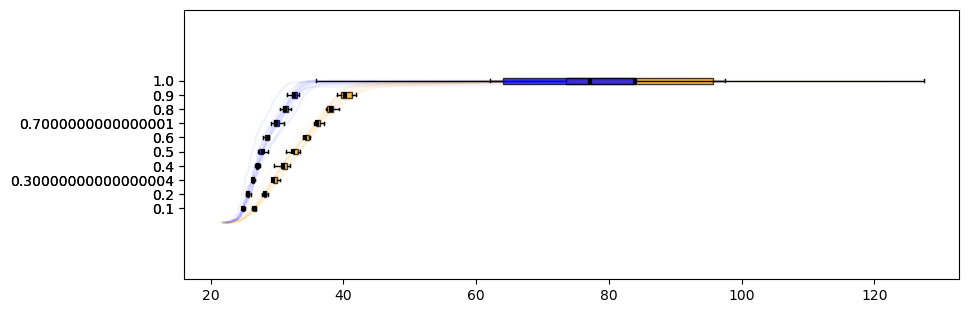

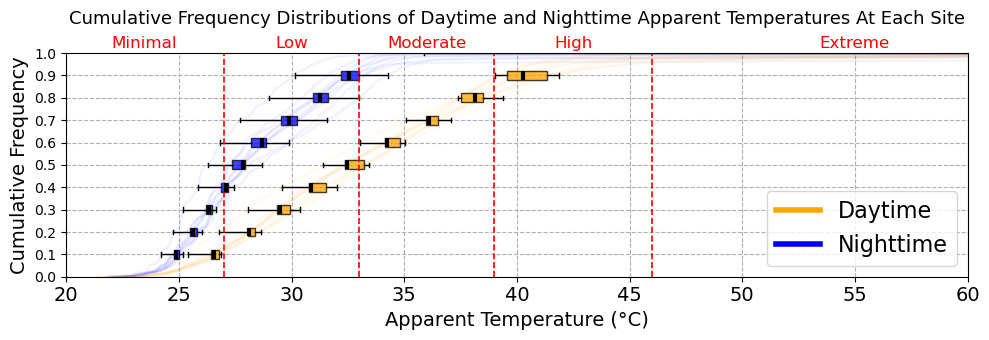

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate a normalized cumulative sum
def compute_cdf(data):
    sorted_data = np.sort(data)
    cumdist = np.linspace(0., 1., len(sorted_data))
    return sorted_data, cumdist

# Function to retrieve heaterature at a given percentile
def get_temperature_at_percentile(sorted_data, cumdist, percentile):
    return np.interp(percentile, cumdist, sorted_data)

# # Define the heat index categories
# heat_ranges =  [27, 33, 39, 46]
# heat_categories = ['Minimal', 'Low', 'Moderate', 'High', 'Extreme']

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 3.5))

daytime_percentile_data = {perc: [] for perc in np.arange(0.1, 1.1, 0.1)}
nighttime_percentile_data = {perc: [] for perc in np.arange(0.1, 1.1, 0.1)}

# Dummy lines for legend
line1, = ax.plot([], [], color='orange', linewidth=4)
line2, = ax.plot([], [], color='blue', linewidth=4)

# Iterate over sites and plot the CDFs
for site in tqdm(sorted_heat_sites.index):
    daytime_values = outdoor_heat[(outdoor_heat['site_id'] == site) & (outdoor_heat['Hour'].isin(daytime_hours))]['Outdoor_Heat_Index'].values
    nighttime_values = outdoor_heat[(outdoor_heat['site_id'] == site) & (outdoor_heat['Hour'].isin(nighttime_hours))]['Outdoor_Heat_Index'].values

    # Filter out nan values
    daytime_values = daytime_values[~np.isnan(daytime_values)]
    nighttime_values = nighttime_values[~np.isnan(nighttime_values)]

    # If there's no data left after filtering, continue to the next site
    if len(daytime_values) == 0 or len(nighttime_values) == 0:
        continue

# Compute CDF for daytime temperatures of this site
    sorted_daytime, cumdist_daytime = compute_cdf(daytime_values)
    ax.plot(sorted_daytime, cumdist_daytime, color='orange', alpha=0.05)
    
    # Compute CDF for nighttime temperatures of this site
    sorted_nighttime, cumdist_nighttime = compute_cdf(nighttime_values)
    ax.plot(sorted_nighttime, cumdist_nighttime, color='blue', alpha=0.05)

    # Retrieve temperature values at each 10th percentile
    for perc in np.arange(0.1, 1.1, 0.1):
        daytime_heat = get_temperature_at_percentile(sorted_daytime, cumdist_daytime, perc)
        nighttime_heat = get_temperature_at_percentile(sorted_nighttime, cumdist_nighttime, perc)
        daytime_percentile_data[perc].append(daytime_heat)
        nighttime_percentile_data[perc].append(nighttime_heat)

# Boxplot properties
medianprops = dict(linestyle='-', linewidth=3, color='black')

# Plot boxplots for daytime and nighttime data at each 10th percentile
for perc, daytime_values in daytime_percentile_data.items():
    ax.boxplot(daytime_values, positions=[perc], widths=0.04, vert=False, patch_artist=True, boxprops=dict(facecolor="orange", alpha=0.75), medianprops=medianprops, showfliers=False)

for perc, nighttime_values in nighttime_percentile_data.items():
    ax.boxplot(nighttime_values, positions=[perc], widths=0.04, vert=False, patch_artist=True, boxprops=dict(facecolor="blue", alpha=0.75), medianprops=medianprops, showfliers=False)

# Add the vertical lines and labels
# for index, heat_range in enumerate(heat_ranges):
#     ax.axvline(heat_range, color='red', linestyle='--', linewidth=1.2)
#     prev_range = heat_ranges[index-1] if index > 0 else 0
#     midpoint = (prev_range + heat_range) / 2import numpy as np
import matplotlib.pyplot as plt

# Function to calculate a normalized cumulative sum
def compute_cdf(data):
    sorted_data = np.sort(data)
    cumdist = np.linspace(0., 1., len(sorted_data))
    return sorted_data, cumdist

# Function to retrieve temperature at a given percentile
def get_temperature_at_percentile(sorted_data, cumdist, percentile):
    return np.interp(percentile, cumdist, sorted_data)

# # Define the heat index categories
heat_ranges =  [27, 33, 39, 46]
heat_categories = ['Minimal', 'Low', 'Moderate', 'High', 'Extreme']

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 3.5))

daytime_percentile_data = {perc: [] for perc in np.arange(0.1, 1.1, 0.1)}
nighttime_percentile_data = {perc: [] for perc in np.arange(0.1, 1.1, 0.1)}

# Dummy lines for legend
line1, = ax.plot([], [], color='orange', linewidth=4)
line2, = ax.plot([], [], color='blue', linewidth=4)

# Iterate over sites and plot the CDFs
for site in tqdm(sorted_heat_sites.index):
    daytime_values = outdoor_heat[(outdoor_heat['site_id'] == site) & (outdoor_heat['Hour'].isin(daytime_hours))]['Outdoor_Heat_Index'].values
    nighttime_values = outdoor_heat[(outdoor_heat['site_id'] == site) & (outdoor_heat['Hour'].isin(nighttime_hours))]['Outdoor_Heat_Index'].values

    # Filter out nan values
    daytime_values = daytime_values[~np.isnan(daytime_values)]
    nighttime_values = nighttime_values[~np.isnan(nighttime_values)]

    # If there's no data left after filtering, continue to the next site
    if len(daytime_values) == 0 or len(nighttime_values) == 0:
        continue

# Compute CDF for daytime temperatures of this site
    sorted_daytime, cumdist_daytime = compute_cdf(daytime_values)
    ax.plot(sorted_daytime, cumdist_daytime, color='orange', alpha=0.05)
    
    # Compute CDF for nighttime temperatures of this site
    sorted_nighttime, cumdist_nighttime = compute_cdf(nighttime_values)
    ax.plot(sorted_nighttime, cumdist_nighttime, color='blue', alpha=0.05)

    # Retrieve temperature values at each 10th percentile
    for perc in np.arange(0.1, 1.1, 0.1):
        daytime_heat = get_temperature_at_percentile(sorted_daytime, cumdist_daytime, perc)
        nighttime_heat = get_temperature_at_percentile(sorted_nighttime, cumdist_nighttime, perc)
        daytime_percentile_data[perc].append(daytime_heat)
        nighttime_percentile_data[perc].append(nighttime_heat)

# Boxplot properties
medianprops = dict(linestyle='-', linewidth=3, color='black')

# Plot boxplots for daytime and nighttime data at each 10th percentile
for perc, daytime_values in daytime_percentile_data.items():
    ax.boxplot(daytime_values, positions=[perc], widths=0.04, whis=10, vert=False, patch_artist=True, boxprops=dict(facecolor="orange", alpha=0.75), medianprops=medianprops, showfliers=False)

for perc, nighttime_values in nighttime_percentile_data.items():
    ax.boxplot(nighttime_values, positions=[perc], widths=0.04, whis=10, vert=False, patch_artist=True, boxprops=dict(facecolor="blue", alpha=0.75), medianprops=medianprops, showfliers=False)

# Add the vertical lines and labels
# for index, heat_range in enumerate(heat_ranges):
#     ax.axvline(heat_range, color='red', linestyle='--', linewidth=1.2)
#     prev_range = heat_ranges[index-1] if index > 0 else 0
#     midpoint = (prev_range + heat_range) / 2
#     y_position = 1.025
#     if index == 0:
#         ax.text(22, y_position, heat_categories[index], horizontalalignment='left', fontsize=12, color='red')
#     else:
#         ax.text(midpoint, y_position, heat_categories[index], horizontalalignment='center', fontsize=12, color='red')

# last_range = heat_ranges[-1]
# # max_x = ax.get_xlim()[1]
# # midpoint = (last_range + max_x) / 2
# ax.text(55, 1.025, heat_categories[-1], horizontalalignment='center', fontsize=12, color='red')

# Add labels, title, legend, etc.
ax.set_xlabel('Temperature (°C)', fontsize = 14)
ax.set_ylabel('Cumulative Frequency', fontsize = 14)
ax.set_title('Cumulative Frequency Distributions of Daytime and Nighttime Temperatures At Each Site', fontsize = 13)
ax.legend([line1, line2], ['Daytime', 'Nighttime'], loc='lower right', fontsize=16)

# Adjust y-axis settings
ax.set_ylim([0, 1])  # Update the y-axis limit
ax.set_xlim([20, 45])  # Update the x-axis limit
ax.set_yticks(np.arange(0, 1.1, 0.1))  
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())  # Fix y-axis tick formatting

# Grid and show
plt.grid(True, which="both", ls="--")
plt.xticks(fontsize = 14)
# plt.ticks(fontsize = 14)
plt.tight_layout()
# plt.savefig('CMF_outdoor_temperatures.png', bbox_inches='tight')

# Add the vertical lines and labels
for index, heat_range in enumerate(heat_ranges):
    ax.axvline(heat_range, color='red', linestyle='--', linewidth=1.2)
    prev_range = heat_ranges[index-1] if index > 0 else 0
    midpoint = (prev_range + heat_range) / 2
    y_position = 1.025
    if index == 0:
        ax.text(22, y_position, heat_categories[index], horizontalalignment='left', fontsize=12, color='red')
    else:
        ax.text(midpoint, y_position, heat_categories[index], horizontalalignment='center', fontsize=12, color='red')

last_range = heat_ranges[-1]
# max_x = ax.get_xlim()[1]
# midpoint = (last_range + max_x) / 2
ax.text(55, 1.025, heat_categories[-1], horizontalalignment='center', fontsize=12, color='red')

# Add labels, title, legend, etc.
ax.set_xlabel('Apparent Temperature (°C)', fontsize = 14)
ax.set_ylabel('Cumulative Frequency', fontsize = 14)
ax.set_title('Cumulative Frequency Distributions of Daytime and Nighttime Apparent Temperatures At Each Site\n', fontsize = 13)
ax.legend([line1, line2], ['Daytime', 'Nighttime'], loc='lower right', fontsize=16)

# Adjust y-axis settings
ax.set_ylim([0, 1])  # Update the y-axis limit
ax.set_xlim([20, 60])  # Update the x-axis limit
ax.set_yticks(np.arange(0, 1.1, 0.1))  
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())  # Fix y-axis tick formatting

# Grid and show
plt.grid(True, which="both", ls="--")
plt.xticks(fontsize = 14)
# plt.ticks(fontsize = 14)
plt.tight_layout()
plt.savefig('paper_plots/CMF_outdoor_apparent_temperatures.png', bbox_inches='tight')


In [12]:
dwelling_variables = ['dwelling_type', 'roof_material', 'roof_shape', 'wall_material', 'floor_material', 'ceiling_material', 'roof_wall_gap', 'roof_colour', 'window_type', 'window_type_other', 'dwelling_floors', 'shade_trees_yesno', 'shade_buildings_yesno', 'aircon_yesno', 'windows_yesno']
for variable in dwelling_variables:
    print(merged_df[variable].value_counts())
    print("\n")

dwelling_type
1    10746
2     8197
4     4716
3     4532
Name: count, dtype: int64


roof_material
4    13991
3    10232
6     1990
1     1978
Name: count, dtype: int64


roof_shape
3.0    15812
1.0    11704
Name: count, dtype: int64


wall_material
2.0     26842
9.0       675
11.0      674
Name: count, dtype: int64


floor_material
3.0    14244
2.0    11335
5.0     1937
Name: count, dtype: int64


ceiling_material
3.0    15984
1.0     4335
4.0     3871
2.0     2651
Name: count, dtype: int64


roof_wall_gap
0.0    25922
1.0     1929
Name: count, dtype: int64


roof_colour
Ash        14336
Silver      2038
Brown       1356
White       1344
Blue        1293
Red         1272
Brown        683
Ash          683
Black        682
Grey         682
Black        634
Green        549
Silver       340
Name: count, dtype: int64


window_type
2.0    14572
4.0     5569
3.0     3995
1.0     3373
Name: count, dtype: int64


window_type_other
No window     3537
Mesh          2032
Name: count, dtype: int

In [25]:
# Define the hours for daytime and nighttime
daytime_hours = list(range(6, 18))
nighttime_hours = list(range(18, 24)) + list(range(0, 6))

# Extracting the date from the timestamp
indoor_heat['Date'] = indoor_heat.index.date

# For each site, for each day, calculate mean of daytime and nighttime heat indices, and max of daytime heat indices
daily_heat_metrics = indoor_heat.groupby(['sensor_id_indoor_temp', 'Date']).progress_apply(lambda group: pd.Series({
    'daily_avg_daytime_temperature': group[group['Hour'].isin(daytime_hours)]['Indoor_Heat_Index'].mean(),
    'daily_avg_nighttime_temperature': group[group['Hour'].isin(nighttime_hours)]['Indoor_Heat_Index'].mean(),
    'daily_max_daytime_temperature': group[group['Hour'].isin(daytime_hours)]['Indoor_Heat_Index'].max()
}))

# Now, average these daily heat metrics over all days for each site
aggregated_heat_data = daily_heat_metrics.groupby('sensor_id_indoor_temp').mean().reset_index()

# You don't need to merge distances here again if you already did it with temperature data, 
# unless you want this to be a standalone DataFrame.
# aggregated_heat_data = aggregated_heat_data.merge(outdoor_temp[['site_id', 'distance']].drop_duplicates(), on='site_id', how='left')
aggregated_heat_data.set_index('sensor_id_indoor_temp', inplace=True)  # Set the site_id back as the index

# Sort the sites by the chosen method
sort_by_heat = 'daily_avg_daytime_temperature'  # or any other column you prefer
sorted_heat_sites = aggregated_heat_data.sort_values(sort_by_heat)


  0%|          | 0/3345 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

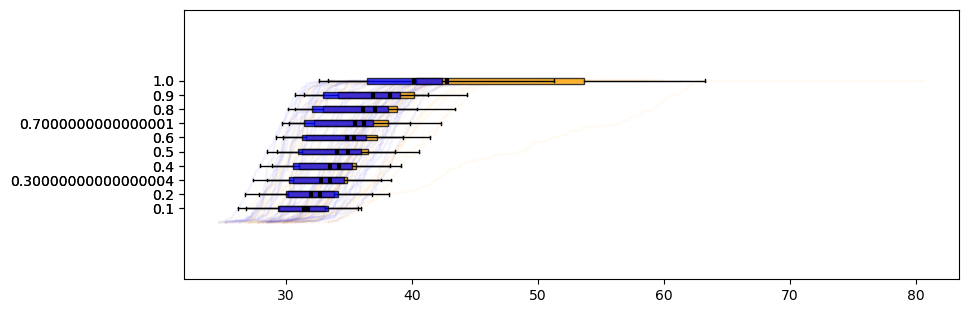

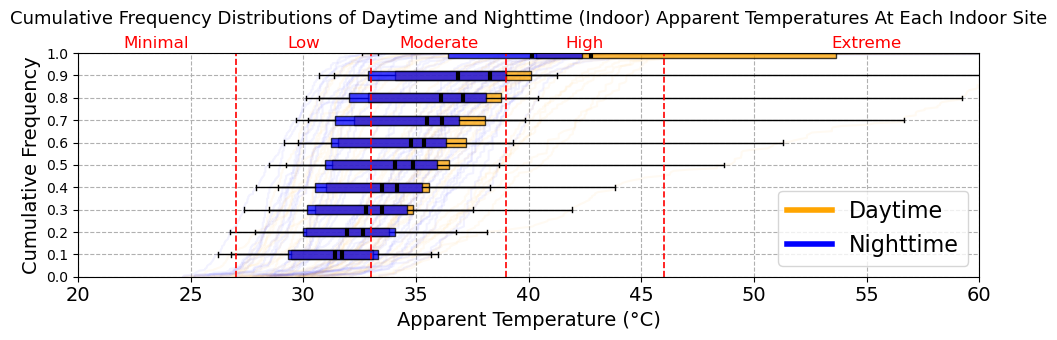

In [26]:
# Set up the figure
fig, ax = plt.subplots(figsize=(10, 3.5))

daytime_percentile_data = {perc: [] for perc in np.arange(0.1, 1.1, 0.1)}
nighttime_percentile_data = {perc: [] for perc in np.arange(0.1, 1.1, 0.1)}

# Dummy lines for legend
line1, = ax.plot([], [], color='orange', linewidth=4)
line2, = ax.plot([], [], color='blue', linewidth=4)

# Iterate over sites and plot the CDFs
for sensor_id in tqdm(sorted_heat_sites.index):
    daytime_values = indoor_heat[(indoor_heat['sensor_id_indoor_temp'] == sensor_id) & (indoor_heat['Hour'].isin(daytime_hours))]['Indoor_Heat_Index'].values
    nighttime_values = indoor_heat[(indoor_heat['sensor_id_indoor_temp'] == sensor_id) & (indoor_heat['Hour'].isin(nighttime_hours))]['Indoor_Heat_Index'].values

    # Filter in nan values
    daytime_values = daytime_values[~np.isnan(daytime_values)]
    nighttime_values = nighttime_values[~np.isnan(nighttime_values)]

    # If there's no data left after filtering, continue to the next site
    if len(daytime_values) == 0 or len(nighttime_values) == 0:
        continue

# Compute CDF for daytime temperatures of this site
    sorted_daytime, cumdist_daytime = compute_cdf(daytime_values)
    ax.plot(sorted_daytime, cumdist_daytime, color='orange', alpha=0.05)
    
    # Compute CDF for nighttime temperatures of this site
    sorted_nighttime, cumdist_nighttime = compute_cdf(nighttime_values)
    ax.plot(sorted_nighttime, cumdist_nighttime, color='blue', alpha=0.05)

    # Retrieve temperature values at each 10th percentile
    for perc in np.arange(0.1, 1.1, 0.1):
        daytime_heat = get_temperature_at_percentile(sorted_daytime, cumdist_daytime, perc)
        nighttime_heat = get_temperature_at_percentile(sorted_nighttime, cumdist_nighttime, perc)
        daytime_percentile_data[perc].append(daytime_heat)
        nighttime_percentile_data[perc].append(nighttime_heat)

# Boxplot properties
medianprops = dict(linestyle='-', linewidth=3, color='black')

# Plot boxplots for daytime and nighttime data at each 10th percentile
for perc, daytime_values in daytime_percentile_data.items():
    ax.boxplot(daytime_values, positions=[perc], widths=0.04, vert=False, patch_artist=True, boxprops=dict(facecolor="orange", alpha=0.75), medianprops=medianprops, showfliers=False)

for perc, nighttime_values in nighttime_percentile_data.items():
    ax.boxplot(nighttime_values, positions=[perc], widths=0.04, vert=False, patch_artist=True, boxprops=dict(facecolor="blue", alpha=0.75), medianprops=medianprops, showfliers=False)

# Add the vertical lines and labels
# for index, heat_range in enumerate(heat_ranges):
#     ax.axvline(heat_range, color='red', linestyle='--', linewidth=1.2)
#     prev_range = heat_ranges[index-1] if index > 0 else 0
#     midpoint = (prev_range + heat_range) / 2import numpy as np
import matplotlib.pyplot as plt

# Function to calculate a normalized cumulative sum
def compute_cdf(data):
    sorted_data = np.sort(data)
    cumdist = np.linspace(0., 1., len(sorted_data))
    return sorted_data, cumdist

# Function to retrieve temperature at a given percentile
def get_temperature_at_percentile(sorted_data, cumdist, percentile):
    return np.interp(percentile, cumdist, sorted_data)

# # Define the heat index categories
heat_ranges =  [27, 33, 39, 46]
heat_categories = ['Minimal', 'Low', 'Moderate', 'High', 'Extreme']

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 3.5))

daytime_percentile_data = {perc: [] for perc in np.arange(0.1, 1.1, 0.1)}
nighttime_percentile_data = {perc: [] for perc in np.arange(0.1, 1.1, 0.1)}

# Dummy lines for legend
line1, = ax.plot([], [], color='orange', linewidth=4)
line2, = ax.plot([], [], color='blue', linewidth=4)

# Iterate over sites and plot the CDFs
for sensor_id in tqdm(sorted_heat_sites.index):
    daytime_values = indoor_heat[(indoor_heat['sensor_id_indoor_temp'] == sensor_id) & (indoor_heat['Hour'].isin(daytime_hours))]['Indoor_Heat_Index'].values
    nighttime_values = indoor_heat[(indoor_heat['sensor_id_indoor_temp'] == sensor_id) & (indoor_heat['Hour'].isin(nighttime_hours))]['Indoor_Heat_Index'].values

    # Filter out nan values
    daytime_values = daytime_values[~np.isnan(daytime_values)]
    nighttime_values = nighttime_values[~np.isnan(nighttime_values)]

    # If there's no data left after filtering, continue to the next site
    if len(daytime_values) == 0 or len(nighttime_values) == 0:
        continue

# Compute CDF for daytime temperatures of this site
    sorted_daytime, cumdist_daytime = compute_cdf(daytime_values)
    ax.plot(sorted_daytime, cumdist_daytime, color='orange', alpha=0.05)
    
    # Compute CDF for nighttime temperatures of this site
    sorted_nighttime, cumdist_nighttime = compute_cdf(nighttime_values)
    ax.plot(sorted_nighttime, cumdist_nighttime, color='blue', alpha=0.05)

    # Retrieve temperature values at each 10th percentile
    for perc in np.arange(0.1, 1.1, 0.1):
        daytime_heat = get_temperature_at_percentile(sorted_daytime, cumdist_daytime, perc)
        nighttime_heat = get_temperature_at_percentile(sorted_nighttime, cumdist_nighttime, perc)
        daytime_percentile_data[perc].append(daytime_heat)
        nighttime_percentile_data[perc].append(nighttime_heat)

# Boxplot properties
medianprops = dict(linestyle='-', linewidth=3, color='black')

# Plot boxplots for daytime and nighttime data at each 10th percentile
for perc, daytime_values in daytime_percentile_data.items():
    ax.boxplot(daytime_values, positions=[perc], widths=0.04, whis=10, vert=False, patch_artist=True, boxprops=dict(facecolor="orange", alpha=0.75), medianprops=medianprops, showfliers=False)

for perc, nighttime_values in nighttime_percentile_data.items():
    ax.boxplot(nighttime_values, positions=[perc], widths=0.04, whis=10, vert=False, patch_artist=True, boxprops=dict(facecolor="blue", alpha=0.75), medianprops=medianprops, showfliers=False)

# Add the vertical lines and labels
# for index, heat_range in enumerate(heat_ranges):
#     ax.axvline(heat_range, color='red', linestyle='--', linewidth=1.2)
#     prev_range = heat_ranges[index-1] if index > 0 else 0
#     midpoint = (prev_range + heat_range) / 2
#     y_position = 1.025
#     if index == 0:
#         ax.text(22, y_position, heat_categories[index], horizontalalignment='left', fontsize=12, color='red')
#     else:
#         ax.text(midpoint, y_position, heat_categories[index], horizontalalignment='center', fontsize=12, color='red')

# last_range = heat_ranges[-1]
# # max_x = ax.get_xlim()[1]
# # midpoint = (last_range + max_x) / 2
# ax.text(55, 1.025, heat_categories[-1], horizontalalignment='center', fontsize=12, color='red')

# Add labels, title, legend, etc.
ax.set_xlabel('Temperature (°C)', fontsize = 14)
ax.set_ylabel('Cumulative Frequency', fontsize = 14)
ax.set_title('Cumulative Frequency Distributions of Daytime and Nighttime Temperatures At Each Indoor Site', fontsize = 13)
ax.legend([line1, line2], ['Daytime', 'Nighttime'], loc='lower right', fontsize=16)

# Adjust y-axis settings
ax.set_ylim([0, 1])  # Update the y-axis limit
ax.set_xlim([20, 45])  # Update the x-axis limit
ax.set_yticks(np.arange(0, 1.1, 0.1))  
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())  # Fix y-axis tick formatting

# Grid and show
plt.grid(True, which="both", ls="--")
plt.xticks(fontsize = 14)
# plt.ticks(fontsize = 14)
plt.tight_layout()
# plt.savefig('CMF_outdoor_temperatures.png', bbox_inches='tight')

# Add the vertical lines and labels
for index, heat_range in enumerate(heat_ranges):
    ax.axvline(heat_range, color='red', linestyle='--', linewidth=1.2)
    prev_range = heat_ranges[index-1] if index > 0 else 0
    midpoint = (prev_range + heat_range) / 2
    y_position = 1.025
    if index == 0:
        ax.text(22, y_position, heat_categories[index], horizontalalignment='left', fontsize=12, color='red')
    else:
        ax.text(midpoint, y_position, heat_categories[index], horizontalalignment='center', fontsize=12, color='red')

last_range = heat_ranges[-1]
# max_x = ax.get_xlim()[1]
# midpoint = (last_range + max_x) / 2
ax.text(55, 1.025, heat_categories[-1], horizontalalignment='center', fontsize=12, color='red')

# Add labels, title, legend, etc.
ax.set_xlabel('Apparent Temperature (°C)', fontsize = 14)
ax.set_ylabel('Cumulative Frequency', fontsize = 14)
ax.set_title('Cumulative Frequency Distributions of Daytime and Nighttime (Indoor) Apparent Temperatures At Each Indoor Site\n', fontsize = 13)
ax.legend([line1, line2], ['Daytime', 'Nighttime'], loc='lower right', fontsize=16)

# Adjust y-axis settings
ax.set_ylim([0, 1])  # Update the y-axis limit
ax.set_xlim([20, 60])  # Update the x-axis limit
ax.set_yticks(np.arange(0, 1.1, 0.1))  
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())  # Fix y-axis tick formatting

# Grid and show
plt.grid(True, which="both", ls="--")
plt.xticks(fontsize = 14)
# plt.ticks(fontsize = 14)
plt.tight_layout()
plt.savefig('paper_plots/CMF_indoor_apparent_temperatures.png', bbox_inches='tight')
